# Using a pretrained model: PANNs with the model CNN6

People often use pretrained models for cases where you have little training data (not a problem for us), for fine grained problems (then it would mabey be more usefull for the multi-label problem) or starting with a stong baseline for the architechture (my biggest benefit). I am experimenting with seeing if pretrained weights outperforms my homebuilt CNN. 

Now I am trying a domaine specific pretrained model. PANNs is trained on audiofiles from AudioSet (which is where FSD50K has ontology from, but not where the actual audio files are from, so my evaluation data is safe. These models have trained on youtube audio files). PANNs has the same labels as me already. I use the model CNN6 which is named so as it has 6 convolutional layers. I use this model as it is computationally lighter (than ResNet18 for example, which took me way to long time).


CNN6 starts stronger than ResNet18 despite being a lighter model, which suggests that domain relevance of pretraining matters more than model size.


In [1]:
#Stuff to set up the PANNs model and get the class labels for the 6 families of sounds we are interested in.

import os
os.makedirs('/Users/livajuliesmidt/panns_data', exist_ok=True)

import urllib.request
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/qiuqiangkong/audioset_tagging_cnn/master/metadata/class_labels_indices.csv',
    '/Users/livajuliesmidt/panns_data/class_labels_indices.csv'
)

from panns_inference import AudioTagging             

In [2]:
from __future__ import print_function, division                     # Ensures Python3 printing & division standard
import IPython.display as ipd                                       #For displaying audio in Jupyter notebooks
import json
import librosa                                                      #For audio processing                    
import matplotlib.pyplot as plt                                     #For creating plots 
import numpy as np                                                  #For numerical operations
import optuna                                                       #For hyperparameter optimization
from optuna.pruners import MedianPruner
import os                                                           #For interacting with the operating system
import pandas as pd                                                 #For data manipulation and analysis      
import random
import seaborn as sns                                               #For statistical data visualization
from sklearn.metrics import roc_curve, auc, average_precision_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import time
import torch
from torch import nn
import torchaudio.transforms as T                                    #For audio transformations like MelSpectrogram
import torch.nn.functional as F                                      #For activation functions and other utilities            
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torchvision.models as models
from tqdm import tqdm
import urllib.request

np.random.seed(42)
random.seed(42)

In [3]:
#Use the internet to import the CNN6 from github
import urllib.request
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/qiuqiangkong/audioset_tagging_cnn/master/pytorch/models.py',
    'panns_models.py'
)

urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/qiuqiangkong/audioset_tagging_cnn/master/pytorch/pytorch_utils.py',
    'pytorch_utils.py'
)

from panns_models import Cnn6

In [4]:
# Set the path to data
DATA_PATH = "/Users/livajuliesmidt/Desktop/ML/AppliedML2026/FinalProject_Liva/FP_data"

dev_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/dev.csv")
train_labels = dev_labels[dev_labels["split"] == "train"]
val_labels = dev_labels[dev_labels["split"] == "val"]
eval_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/eval.csv")

subset_percentage = 100
print(f"Using {subset_percentage}% of the training data equaling {int(len(train_labels) * subset_percentage / 100)} samples")
train_subset = train_labels.sample(n=int(len(train_labels) * subset_percentage / 100), random_state=42)

Using 100% of the training data equaling 36796 samples


In [5]:
#Function for extracting the spectrogram from an audio file, ensuring a fixed shape of (64, 216)
TARGET_SR = 32000                                       #Sample rate TO MATCH CNN6's EXPECTED SAMPLE RATE
DURATION = 5.0                                          #Seconds to keep (clip/pad to this length)
N_MELS = 64                                             #Number of mel bands to generate (bins in the spectrogram)
HOP_LENGTH = 320                                        #Number of samples between successive frames in the spectrogram ALSO TO MATCH CNN6's EXPECTED HOP LENGTH
N_FRAMES = int(TARGET_SR * DURATION / HOP_LENGTH) + 1   #Number of frames in the spectrogram (~216 frames)

    
def extract_spectrogram(filepath):
    try:
        audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
        
        # Tile (repeat) if shorter than 5 seconds
        expected_samples = int(TARGET_SR * DURATION)
        if len(audio) < expected_samples:
            repeats = -(-expected_samples // len(audio))
            audio = np.tile(audio, repeats)[:expected_samples]
        
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = mel_db[:, :N_FRAMES]  # Trim only — padding is already handled above
        
        return mel_db  # Shape: (64, 216)
    except:
        return None

In [6]:

# --- CNN6 from PANNs adapted for 6-class classification ---
class AudioCNN6(nn.Module):
    def __init__(self, n_classes, dropout, checkpoint_path):
        super().__init__()
        # Load pretrained CNN6 architecture and weights
        self.backbone = Cnn6(
            sample_rate=32000, window_size=1024, hop_size=320,
            mel_bins=64, fmin=50, fmax=14000, classes_num=527
        )
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        self.backbone.load_state_dict(checkpoint['model'])

        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Replace classifier head for 6 classes
        self.backbone.fc1 = nn.Linear(512, 512)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        # x arrives as (batch, 1, 64, 216)
        x = x.squeeze(1)           # → (batch, 64, 216)
        x = x.transpose(1, 2)      # → (batch, 216, 64)
        x = x.unsqueeze(1)         # → (batch, 1, 216, 64) — CNN6 conv blocks expect this

        # Skip CNN6's internal spectrogram computation, go straight to conv blocks
        x = self.backbone.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.backbone.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.backbone.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.backbone.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = torch.mean(x, dim=3)
        x1, _ = torch.max(x, dim=2)
        x2 = torch.mean(x, dim=2)
        embedding = x1 + x2
        return self.head(embedding)


## Preprocessing training and validation data

In [6]:
print("Extracting 2D spectrograms from train split...")
spectrograms = []
valid_idx = []  

for i, row in tqdm(train_subset.iterrows(), total=len(train_subset)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_train = np.array(spectrograms)              # (n_clips, 64, 216)
X_train = X_train[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
train_true = train_subset.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_train shape: {X_train.shape}")

print(f"Number of successfully processed samples: {len(train_true)}")
print(f"Number of unsuccessful samples: {len(train_subset) - len(train_true)}")

#took 8 minutes

Extracting 2D spectrograms from train split...


100%|██████████| 36796/36796 [06:53<00:00, 88.88it/s]


X_train shape: (36796, 1, 64, 501)
Number of successfully processed samples: 36796
Number of unsuccessful samples: 0


In [7]:
print("Extracting 2D spectrograms from validation split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(val_labels.iterrows(), total=len(val_labels)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_val = np.array(spectrograms)              # (n_clips, 64, 216)
X_val = X_val[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
val_true = val_labels.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_val shape: {X_val.shape}")

print(f"Number of successfully processed samples: {len(val_true)}")
print(f"Number of unsuccessful samples: {len(val_labels) - len(val_true)}")

#took 1 minute


Extracting 2D spectrograms from validation split...


100%|██████████| 4170/4170 [00:52<00:00, 80.17it/s]


X_val shape: (4170, 1, 64, 501)
Number of successfully processed samples: 4170
Number of unsuccessful samples: 0


In [8]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std  # use train stats, not val stats!

#takes 4 min

In [7]:
url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
urllib.request.urlretrieve(url, "ontology.json")

with open("ontology.json") as f:
    ontology = json.load(f)

ontology_by_id = {entry["id"]: entry for entry in ontology}     # Build a lookup: mid → full entry

child_to_parent = {}                                            # Build a reverse lookup: child_mid → parent_mid
for entry in ontology:
    for child_id in entry["child_ids"]:
        child_to_parent[child_id] = entry["id"]


top_level = {                                                   # The 6 top-level family MIDs (updated to match the discovered ontology structure)
    "/m/0dgw9r": "Human sounds",
    "/m/0jbk":   "Animal",
    "/m/04rlf":  "Music",
    "/m/059j3w": "Natural sounds",
    "/t/dd00041": "Sounds of things",
    "/t/dd00098": "Source-ambiguous sounds",
}

def get_top_level_family(mid):
    current = mid
    while current not in top_level:
        parent = child_to_parent.get(current)
        if parent is None:
            return "Unknown"                                    # shouldn't happen for FSD50K classes
        current = parent
    return top_level[current]




In [10]:
train_true["family"] = train_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
val_true["family"] = val_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(train_true["family"])

print(train_true["family"].value_counts())
print(f"Classes: {len(le.classes_)}, y_train shape: {y_train.shape}")


NameError: name 'train_true' is not defined

In [12]:
# --- Create these ONCE, before the objective function ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)                                                          #Convert training data to PyTorch tensor of type float32
y_train_t = torch.tensor(y_train, dtype=torch.long)                                                             #Convert training labels to PyTorch tensor of type long (integer class indices) 
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t  = torch.tensor(le.transform(val_true["family"]), dtype=torch.long)


n_classes = len(le.classes_) 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")                                    #Use Apple Silicon GPU if available, otherwise CPU
X_val_t_device = X_val_t.to(device)

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

#takes 0.5 min

In [ ]:
from datetime import datetime

number_of_epochs = 30

# --- Hyperparameters ---   #and previous values for reference
lr           = 1e-3         #5.794088198249058e-05 head-only training can use a much higher lr
dropout      = 0.20101305365481736
batch_size   = 32           #I used 32 for my own cnn and 64 for the ResNet18, change to 64 for it to be 10% faster, but more heavy on memory
weight_decay = 0.0008002473325738101


# --- CNN6 from PANNs adapted for 6-class classification ---
class AudioCNN6(nn.Module):
    def __init__(self, n_classes, dropout, checkpoint_path):
        super().__init__()
        # Load pretrained CNN6 architecture and weights
        self.backbone = Cnn6(
            sample_rate=32000, window_size=1024, hop_size=320,
            mel_bins=64, fmin=50, fmax=14000, classes_num=527
        )
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        self.backbone.load_state_dict(checkpoint['model'])

        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Replace classifier head for 6 classes
        self.backbone.fc1 = nn.Linear(512, 512)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        # x arrives as (batch, 1, 64, 216)
        x = x.squeeze(1)           # → (batch, 64, 216)
        x = x.transpose(1, 2)      # → (batch, 216, 64)
        x = x.unsqueeze(1)         # → (batch, 1, 216, 64) — CNN6 conv blocks expect this

        # Skip CNN6's internal spectrogram computation, go straight to conv blocks
        x = self.backbone.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.backbone.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.backbone.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.backbone.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = torch.mean(x, dim=3)
        x1, _ = torch.max(x, dim=2)
        x2 = torch.mean(x, dim=2)
        embedding = x1 + x2
        return self.head(embedding)


model = AudioCNN6(n_classes, dropout, 
                  checkpoint_path="CNN6_weights/Cnn6_mAP=0.343.pth").to(device)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs, eta_min=1e-6)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size, sampler=sampler, num_workers=0)

criterion = nn.CrossEntropyLoss()

## Training the model

In [ ]:
# --- Early stopping setup ---
best_val_map = 0.0
patience = 7
epochs_without_improvement = 0
best_model_state = None

# --- Training loop --- #not training the backbone, only the tiny head
for epoch in range(number_of_epochs):
    model.train()
    all_train_preds = []
    all_train_labels = []
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{number_of_epochs}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        all_train_preds.append(out.argmax(1).detach().cpu())
        all_train_labels.append(yb.cpu())

    train_acc = (torch.cat(all_train_preds) == torch.cat(all_train_labels)).float().mean().item()

    # Validation mAP + accuracy
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(X_val_t_device), 256), desc="Validation"):
            xb = X_val_t_device[i:i+256]
            probs = torch.softmax(model(xb), dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    y_bin = label_binarize(y_val_t.numpy(), classes=list(range(n_classes)))
    val_map = average_precision_score(y_bin, all_probs, average="macro")
    val_acc = (np.argmax(all_probs, axis=1) == y_val_t.numpy()).mean()

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Val mAP: {val_map:.3f}")
    scheduler.step()

    # --- Early stopping check ---
    if val_map > best_val_map:
        best_val_map = val_map
        epochs_without_improvement = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1} — no improvement for {patience} epochs")
            break

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "6_model_CNN6_map_{:.4f}_{}.pth".format(best_val_map, datetime.now().strftime('%Y-%m-%d %H:%M')))
print(f"Restored best model with val mAP: {best_val_map:.4f}")

#25 minutes pr. epoch"""

Validation: 100%|██████████| 17/17 [04:59<00:00, 17.59s/it]


Epoch 01 | Train Acc: 0.631 | Val Acc: 0.614 | Val mAP: 0.655


Validation: 100%|██████████| 17/17 [01:21<00:00,  4.81s/it]


Epoch 02 | Train Acc: 0.674 | Val Acc: 0.615 | Val mAP: 0.680


Validation: 100%|██████████| 17/17 [03:50<00:00, 13.54s/it]


...

Epoch 15 | Train Acc: 0.699 | Val Acc: 0.635 | Val mAP: 0.708


Validation: 100%|██████████| 17/17 [01:07<00:00,  4.00s/it]


Epoch 16 | Train Acc: 0.693 | Val Acc: 0.634 | Val mAP: 0.712


Validation: 100%|██████████| 17/17 [03:55<00:00, 13.83s/it]


Epoch 17 | Train Acc: 0.702 | Val Acc: 0.620 | Val mAP: 0.707
Early stopping at epoch 17 — no improvement for 7 epochs
Restored best model with val mAP: 0.7121


## Validation

In [1]:
# --- Get predicted probabilities for all val samples ---
model.eval()
all_probs = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        probs = torch.softmax(model(xb), dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)  # (n_val_samples, 6)

# --- Binarize true labels for one-vs-rest ---
y_val_np = y_val_t.numpy()
y_bin = label_binarize(y_val_np, classes=list(range(n_classes)))  # (n_val_samples, 6)

# --- Plot ROC curves ---
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - (6 Families) - PANNs CNN6")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("6_families_CNN6_weighted_ROC_curves{}.png".format(datetime.now().strftime('%Y-%m-%d %H-%M')))
plt.show()

#calculate the Mean accurate prediction (mAP) for the validation set
mAP = average_precision_score(y_bin, all_probs, average="macro")
print(f"Mean Average Precision (mAP): {mAP:.4f}")


NameError: name 'model' is not defined

In [24]:
map_5 = average_precision_score(y_bin[:, :5], all_probs[:, :5], average="macro")
print(f"Mean Average Precision (mAP) for the 5 classes (Excluding Source-Ambiguous Sounds): {map_5:.4f}")

Mean Average Precision (mAP) for the 5 classes (Excluding Source-Ambiguous Sounds): 0.7572


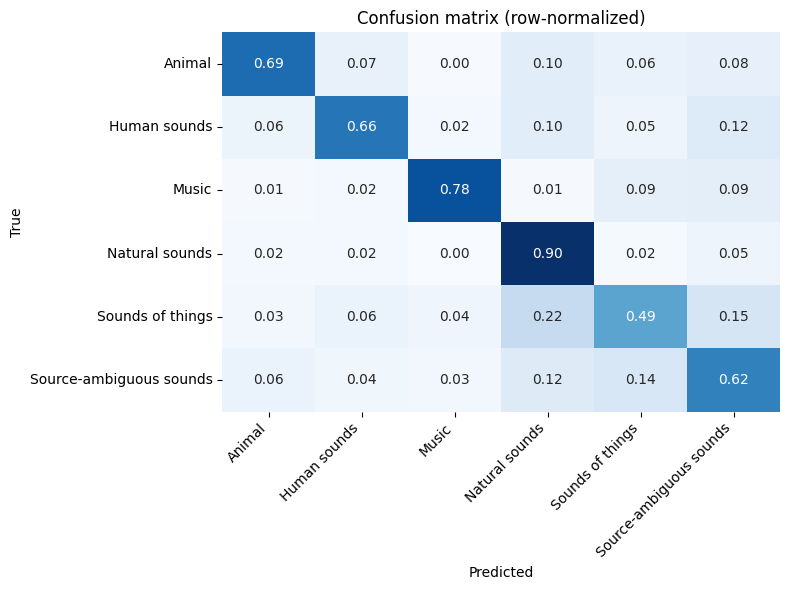

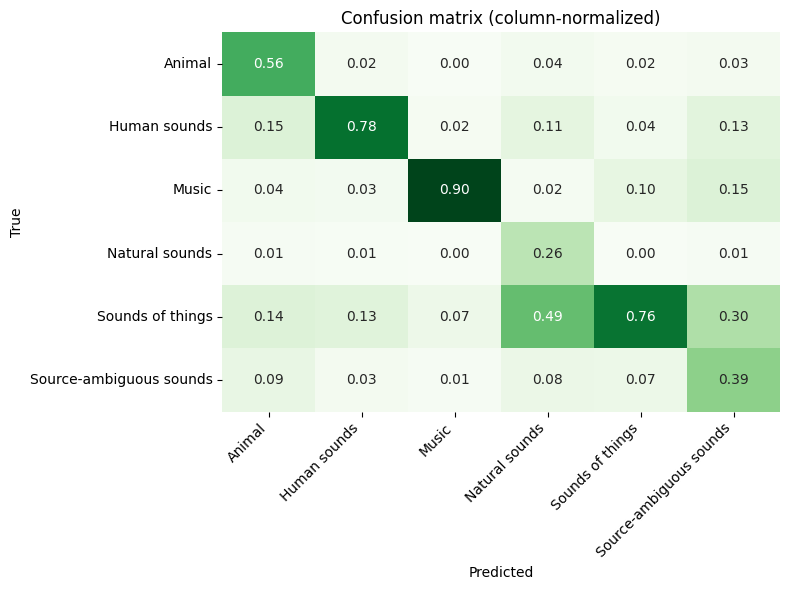

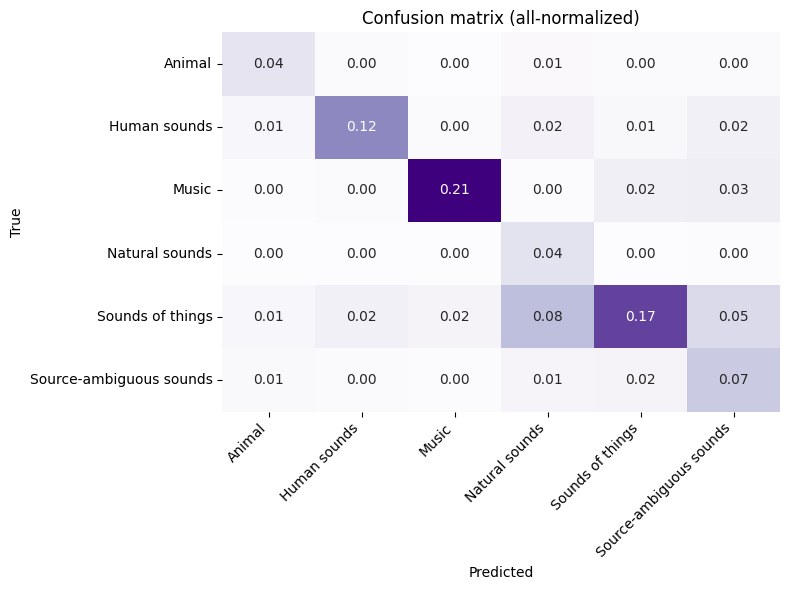

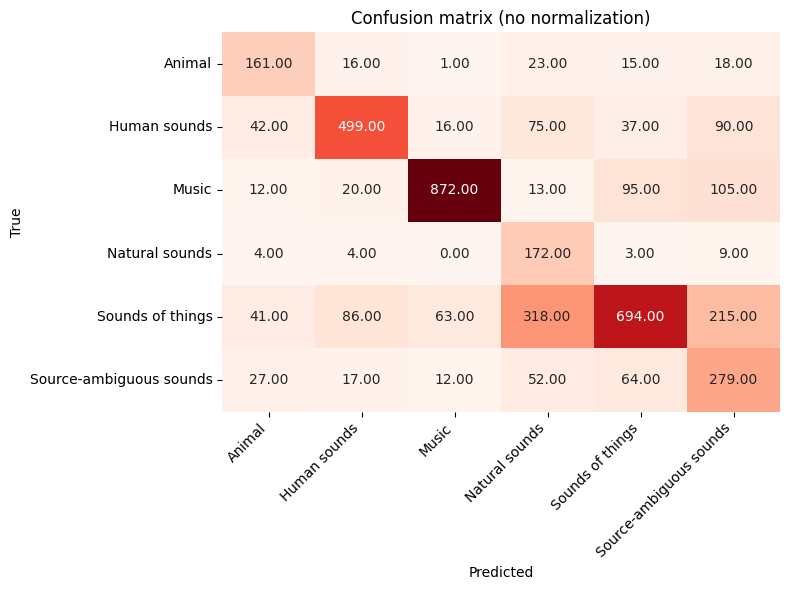

In [21]:
# Get predictions on validation set
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        preds = model(xb).argmax(1).cpu()
        all_preds.append(preds)

all_preds = torch.cat(all_preds).numpy()
y_val_np  = y_val_t.numpy()

# Confusion matrix
cm = confusion_matrix(y_val_np, all_preds, normalize='true')
cm_pred = confusion_matrix(y_val_np, all_preds, normalize='pred')
cm_all = confusion_matrix(y_val_np, all_preds, normalize='all')
cm_numbers = confusion_matrix(y_val_np, all_preds, normalize=None)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (row-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix{}.png".format(datetime.now().strftime('%Y-%m-%d %H:%M')), dpi=300)  # Save the confusion matrix as a high-resolution image
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pred, annot=True, fmt='.2f', cmap='Greens', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (column-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_all, annot=True, fmt='.2f', cmap='Purples', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (all-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_numbers, annot=True, fmt='.2f', cmap='Reds', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (no normalization)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Evaluation

In [8]:
#mean, std depends on the data, so it does not change from run to run
mean, std, dropout = np.load(f"models/Models_6_fam_oversampling/Models_6_fam_oversampling_2026-06-07 16:12/train_stats.npy")
le = LabelEncoder()
le.classes_ = np.load(f"models/Models_6_fam_oversampling/Models_6_fam_oversampling_2026-06-07 16:12/label_encoder_classes.npy", allow_pickle=True)
n_classes = len(le.classes_)
print(f"Loaded train stats: mean={mean:.4f}, std={std:.4f}, dropout={dropout:.4f}")


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

Loaded train stats: mean=-48.8572, std=21.5675, dropout=0.2010


In [9]:
# --- Load best saved model and predict on eval data ---

# 1. Extract eval spectrograms
print("Extracting spectrograms from eval split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(eval_labels.iterrows(), total=len(eval_labels)):
    filepath = f"{DATA_PATH}/FSD50K.eval_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_eval = np.array(spectrograms)
X_eval = X_eval[:, np.newaxis, :, :]
eval_true = eval_labels.loc[valid_idx].reset_index(drop=True)

Extracting spectrograms from eval split...


 40%|███▉      | 4085/10231 [00:49<01:10, 87.78it/s]/var/folders/cn/3wggtrs54wd25m8nnjtry4fh0000gn/T/ipykernel_39101/387253264.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
/Users/livajuliesmidt/anaconda3/envs/app-ml/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 10231/10231 [01:58<00:00, 86.53it/s]


In [11]:
# 2. Normalize using train stats (same mean/std as training!)
print(f"Normalizing eval data using train mean/std...")

X_eval = (X_eval - mean) / std

# 3. Assign family labels
print(f"Assigning family labels to eval data...")
eval_true["family"] = eval_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
y_eval = le.transform(eval_true["family"])

# 4. Convert to tensors
print(f"Converting eval data to PyTorch tensors...")
X_eval_t = torch.tensor(X_eval, dtype=torch.float32).to(device)
y_eval_t = torch.tensor(y_eval, dtype=torch.long)

Normalizing eval data using train mean/std...
Assigning family labels to eval data...
Converting eval data to PyTorch tensors...


In [12]:
# 5. Load saved model
print(f"Loading saved model...")
model_eval = AudioCNN6(n_classes, dropout,
                       checkpoint_path="CNN6_weights/Cnn6_mAP=0.343.pth").to(device)
model_eval.load_state_dict(torch.load("6_model_CNN6_map_0.7121_2026-06-06 22:30.pth",
                                       map_location=device, weights_only=False))

model_eval.eval()


Loading saved model...


AudioCNN6(
  (backbone): Cnn6(
    (spectrogram_extractor): Spectrogram(
      (stft): STFT(
        (conv_real): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
        (conv_imag): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
      )
    )
    (logmel_extractor): LogmelFilterBank()
    (spec_augmenter): SpecAugmentation(
      (time_dropper): DropStripes()
      (freq_dropper): DropStripes()
    )
    (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv_block1): ConvBlock5x5(
      (conv1): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv_block2): ConvBlock5x5(
      (conv1): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv_block3): Con

In [13]:

# 6. Predict
print(f"Predicting on eval data...")
all_probs_eval = []
with torch.no_grad():
    for i in tqdm(range(0, len(X_eval_t), 256), desc="Predicting"):
        xb = X_eval_t[i:i+256]
        probs = torch.softmax(model_eval(xb), dim=1).cpu().numpy()
        all_probs_eval.append(probs)

all_probs_eval = np.vstack(all_probs_eval)

# 7. Metrics
print(f"Calculating metrics on eval data...")
y_bin_eval = label_binarize(y_eval_t.numpy(), classes=list(range(n_classes)))
eval_map = average_precision_score(y_bin_eval, all_probs_eval, average="macro")
eval_acc = (np.argmax(all_probs_eval, axis=1) == y_eval_t.numpy()).mean()

print("Successfully predicted on eval set!")
print(f"Eval Acc: {eval_acc:.3f} | Eval mAP: {eval_map:.3f}")

Predicting on eval data...


Predicting: 100%|██████████| 40/40 [09:32<00:00, 14.32s/it]


Calculating metrics on eval data...
Successfully predicted on eval set!
Eval Acc: 0.577 | Eval mAP: 0.624


In [14]:
# 8. Save predictions with true and predicted family per file
pred_indices = np.argmax(all_probs_eval, axis=1)
eval_true["predicted_family"] = le.inverse_transform(pred_indices)
eval_true["correct"] = eval_true["family"] == eval_true["predicted_family"]
eval_true.to_csv("6_eval_predictions_CNN6.csv", index=False)
print("Predictions saved to 6_eval_predictions_CNN6.csv")

Predictions saved to 6_eval_predictions_CNN6.csv


Plotting ROC curves for eval set...


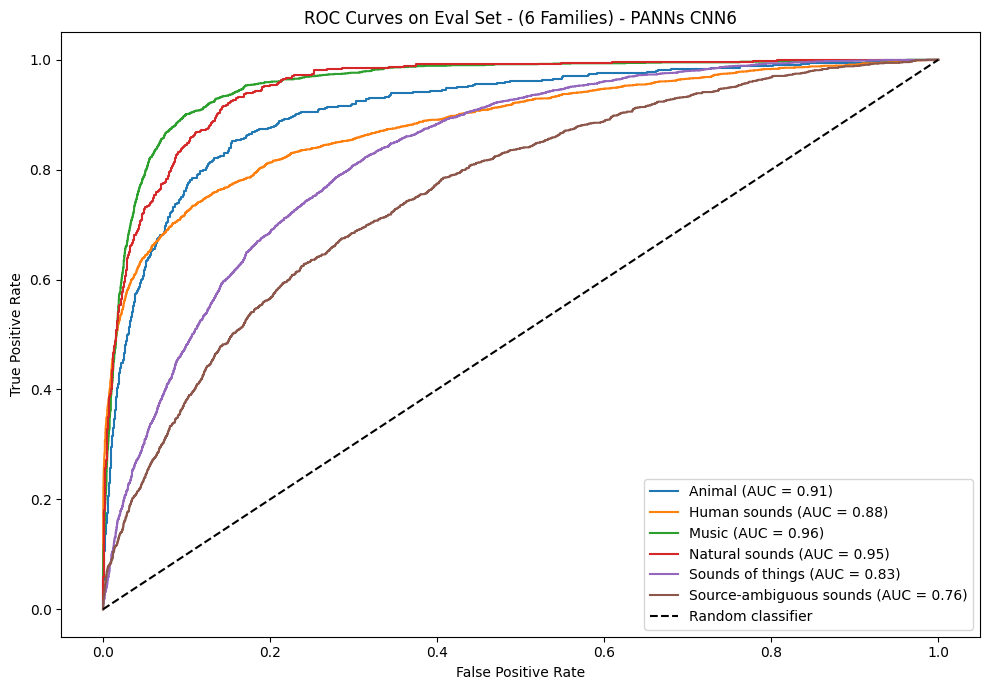

In [16]:
from datetime import datetime

#Plotting ROC curves for eval set
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin_eval[:, i], all_probs_eval[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
print("Plotting ROC curves for eval set...")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Eval Set - (6 Families) - PANNs CNN6")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ROC_Curves_Eval_PANNs_CNN6_families_oversampling_{}.png".format(datetime.now().strftime('%Y-%m-%d %H-%M')), dpi=300)
plt.show()

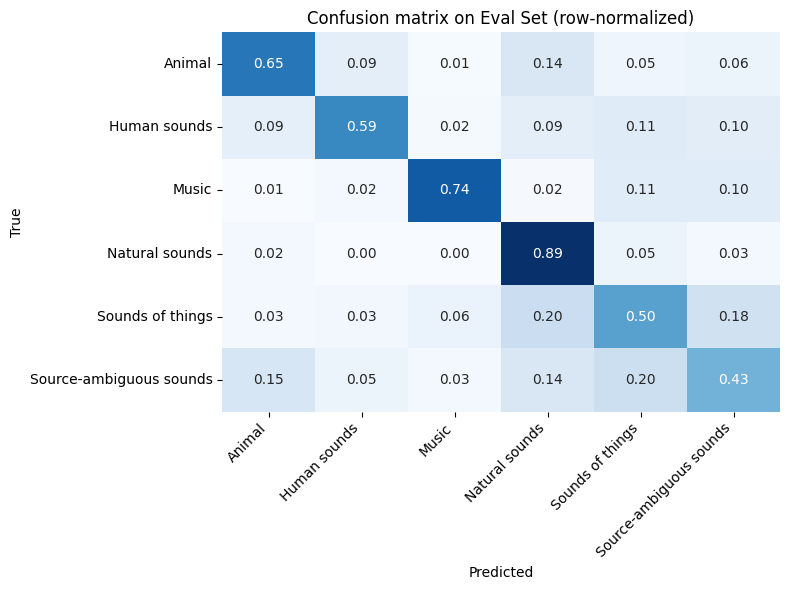

In [17]:
# Calculate confusion matrix for eval set
pred_labels_eval = np.argmax(all_probs_eval, axis=1)
cm_eval = confusion_matrix(y_eval_t.numpy(), pred_labels_eval, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_eval, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix on Eval Set (row-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix_eval_PANNs_CNN6_{}.png".format(datetime.now().strftime('%Y-%m-%d %H-%M')), dpi=300)
plt.show()